In [1]:
name = "circle36"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True)
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt

DB_FILE = name+".db"
DB_FILE_ro = "file:"+name+".db?mode=ro"

In [3]:
conn = sqlite3.connect(DB_FILE_ro, uri=True)
query_metadata = """
SELECT id, startDate, completionDate, computerName, size, rs, eta, prefactors, T_bot, T_top, temperature_description, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY startDate DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
experimentID = int(df_exp['id'].iloc[0])#df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot = df_exp['T_bot'].iloc[0]
T_top = df_exp['T_top'].iloc[0]
temperature_description = df_exp['temperature_description'].iloc[0]
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = df_exp['allgather_time'].iloc[0]
startDate = df_exp['startDate'].iloc[0]
completionDate = df_exp['completionDate'].iloc[0]
if temperature_description =='linear':
    temperature_description_string = ' wrong notebook!'
elif temperature_description =='geometric':
    temp_of_bin = lambda i : round(T_bot*pow((T_top/T_bot), i/(size-1)), 6)
    temperature_description_string = ' temperature intervals are discretised geometrically into '+str(size)+' bins'
else:
    temperature_description_string = ' temperature intervals discretised into '+str(number_of_rounds//2)+' bins, all parallel systems anneal at the same fixed temperature, temperature intervals traversed from low to high then back to low'

#initial Config data ---> taken from first frame of rank 0
cur = conn.cursor()
cur.execute("""SELECT * FROM _experiments_all_curves WHERE experimentID = ? AND frameNumber = 1 AND rankNumber = 0 """, (experimentID,))
row = cur.fetchone()
edgeLength = row[8]
curveLength =  row[7]
sphereCount = row[9]
reachConstraint = row[10]
cur.execute("""SELECT inputSphereRadius FROM _measures WHERE curveID = ?""", (row[0], ))
inputSphereRadius = cur.fetchone()[0]

conn.close()

MARKDOWN='''## Experimenting with '''+name+''' experiment id $='''+str(experimentID)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, and embedded tube radius $'''+str(reachConstraint)+'''$ the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, '''+temperature_description_string+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with circle36 experiment id $=55$

- $r_{s} = 0.1$, and  $\eta =0.05$ with input sphere $R(1 + r_{s}^{*}) = 1.10856$, and embedded tube radius $143$ the curve is interpolated with 0.25 balls with (fixed) approximate edge length $dl=35.75$.

- Coefficients are $\alpha_{0} = 59.95606$, $\alpha_{1} = -0.45881$, $\alpha_{2} = 0.00595$, $\alpha_{3} = 0.0007$

- Computing over 10 systems  with temperature $T\in[0.001,0.1]$,  wrong notebook!.

- Each round lasting 1200.0 seconds for 3 rounds.

- Experiment computed for 0.042 days.

In [4]:
experimentID

55

In [5]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [6]:
with sqlite3.connect(DB_FILE_ro, uri=True) as conn: #closing automatically handled with "with ..."
    query_curves = f"""
    SELECT id, frameNumber, rankNumber, time_in_sequence, temperature, energy, L
    FROM _experiments_all_curves 
    WHERE experimentID = {experimentID}
    ORDER BY rankNumber, frameNumber
    """
    df_curves = pd.read_sql_query(query_curves, conn)
    curve_ids_str = ",".join(map(str, df_curves['id'].unique()))
    
    query_measures = f"""
    SELECT * FROM _measures 
    WHERE curveID IN ({curve_ids_str})
    """
    df_measures = pd.read_sql_query(query_measures, conn)
    

In [7]:
df_curves.head()

,id,frameNumber,rankNumber,time_in_sequence,temperature,energy,L
0,1,1,0,0.006720,0.001,-5.987075,35.75
1,2,2,0,273.699250,0.001,-6.067815,35.75
2,3,3,0,551.601833,0.001,-6.095628,35.75
3,4,4,0,835.861915,0.001,-6.086472,35.75
4,5,5,0,1122.369781,0.001,-6.114928,35.75


In [8]:
print(df_curves['temperature'].unique())

[0.001  0.0109 0.0208 0.0307 0.0406 0.0505 0.0604 0.0703 0.0802 0.0901]


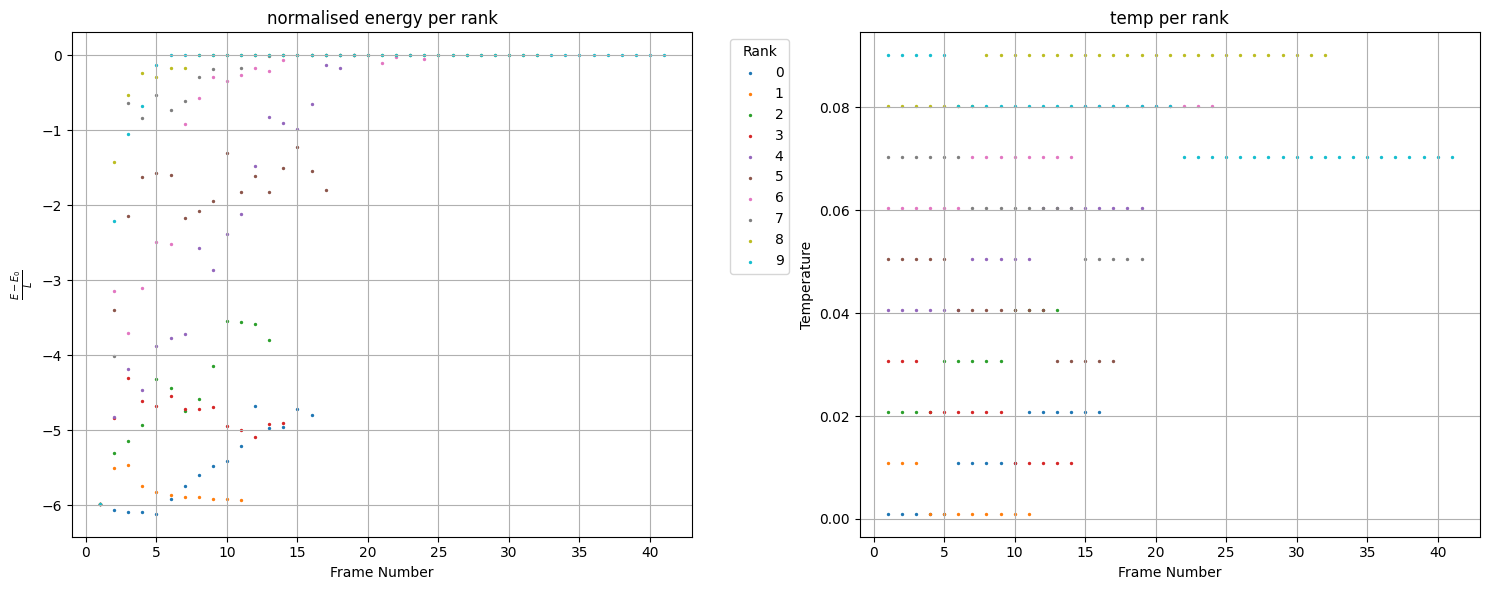

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for rank, group in df_curves.groupby('rankNumber'):
    ax1.scatter(group['frameNumber'], group['energy'], s=2, label=f"{rank}")
    ax2.scatter(group['frameNumber'], group['temperature'], s=2, label=f"{rank}")

ax1.set_ylabel(r"$\frac{E - E_{0}}{L}$")
ax1.set_xlabel("Frame Number")
ax1.set_title("normalised energy per rank")
ax1.grid()
ax1.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.set_xlabel("Frame Number")
ax2.set_ylabel("Temperature")
ax2.set_title("temp per rank")
ax2.grid()

plt.tight_layout()

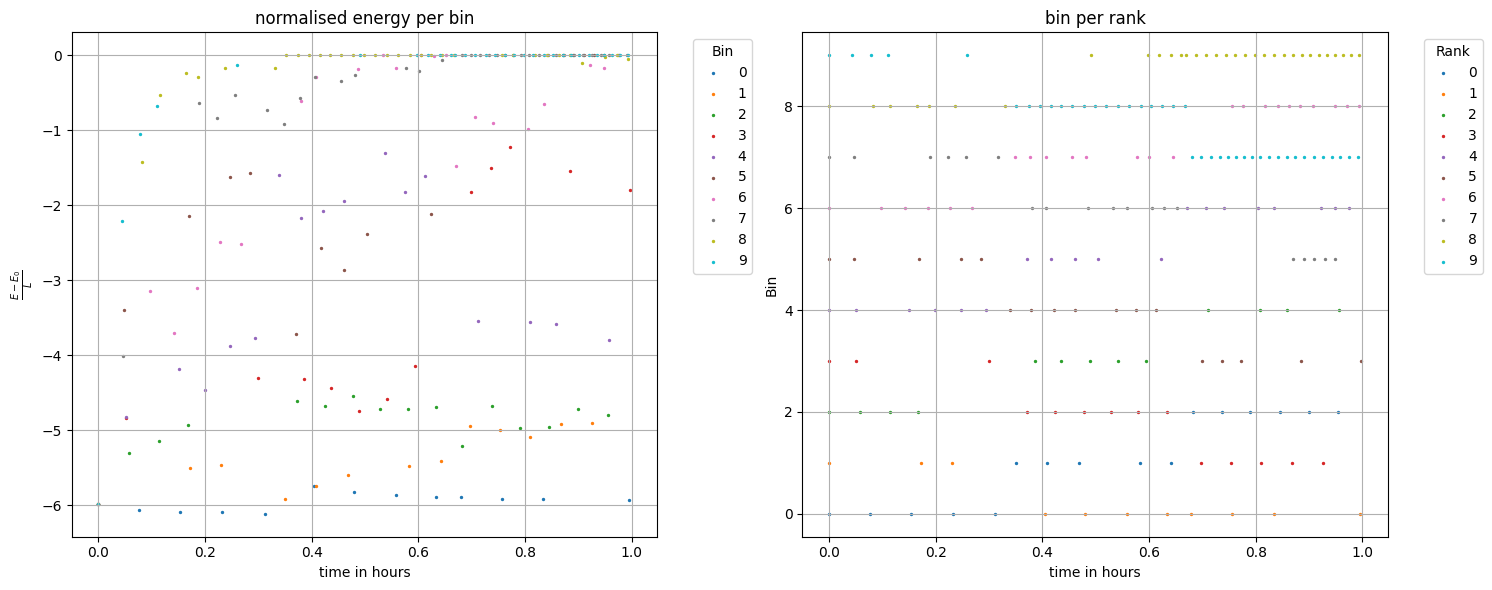

In [17]:
sorted_temps = sorted(df_curves['temperature'].unique())
temp_to_bin = {t: i for i, t in enumerate(sorted_temps)}
df_curves['bin_index'] = df_curves['temperature'].map(temp_to_bin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for bin_index, group in df_curves.groupby('bin_index'):
    ax1.scatter(group['time_in_sequence']/(60*60), group['energy'], s=2, label=f"{bin_index}")

for rank, group in df_curves.groupby('rankNumber'):
    ax2.scatter(group['time_in_sequence']/(60*60), group['bin_index'], s=2, label=f"{rank}")

ax1.set_xlabel("time in hours")
ax1.set_ylabel(r"$\frac{E - E_{0}}{L}$")
ax1.set_title("normalised energy per bin")
ax1.grid()
ax1.legend(title="Bin", bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.set_xlabel("time in hours")
ax2.set_ylabel("Bin")
ax2.set_title("bin per rank")
ax2.grid()
ax2.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

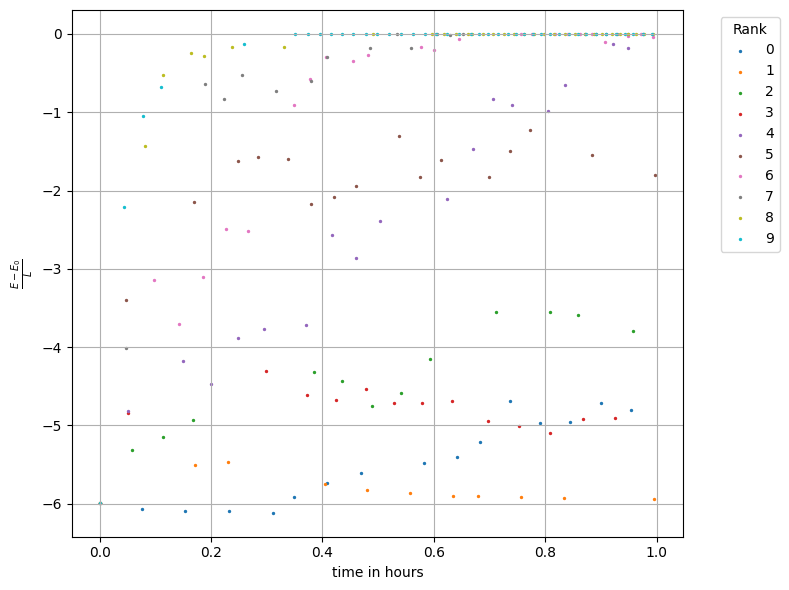

In [10]:
plt.figure(figsize=(8, 6))
for rank, group in df_curves.groupby('rankNumber'):
    plt.scatter((np.array(group['time_in_sequence'])/(60*60)).tolist(), group['energy'], s=2, label=f"{rank}")

plt.xlabel("time in hours")
plt.ylabel(r"$\frac{E - E_{0}}{L}$")
plt.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()

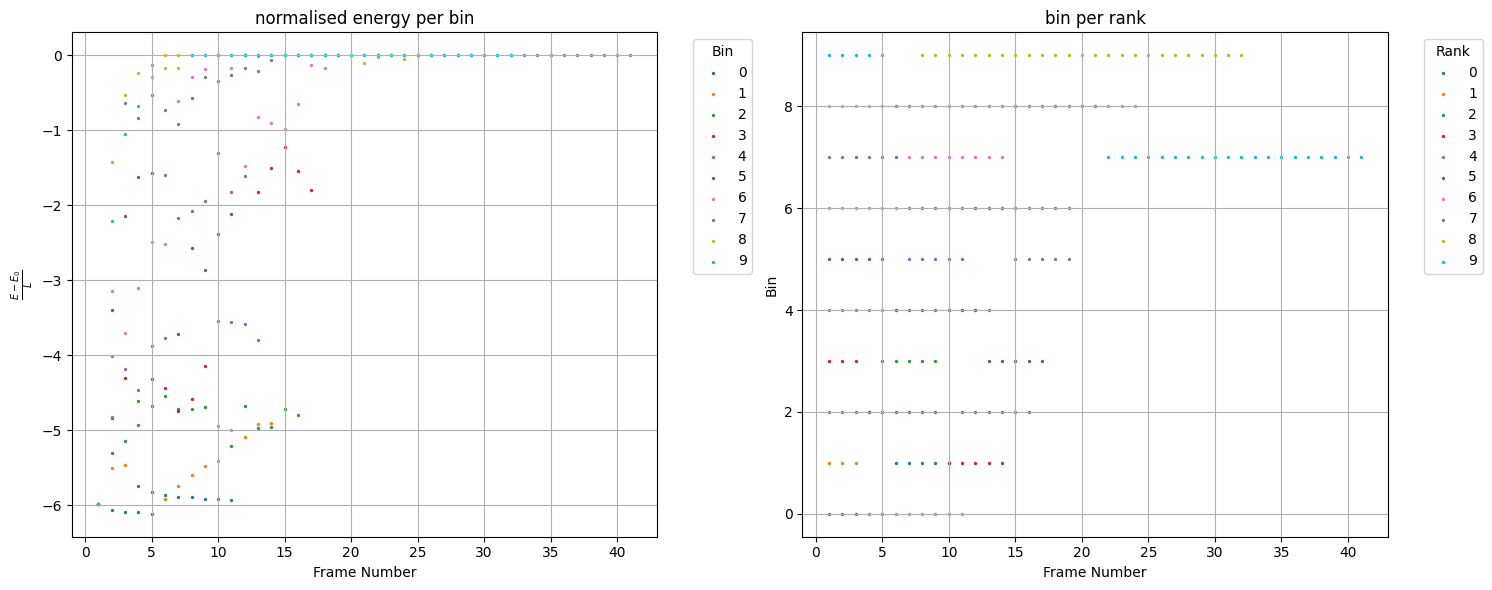

In [16]:
sorted_temps = sorted(df_curves['temperature'].unique())
temp_to_bin = {t: i for i, t in enumerate(sorted_temps)}
df_curves['bin_index'] = df_curves['temperature'].map(temp_to_bin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for bin_index, group in df_curves.groupby('bin_index'):
    ax1.scatter(group['frameNumber'], group['energy'], s=2, label=f"{bin_index}")

for rank, group in df_curves.groupby('rankNumber'):
    ax2.scatter(group['frameNumber'], group['bin_index'], s=2, label=f"{rank}")

ax1.set_ylabel(r"$\frac{E - E_{0}}{L}$")
ax1.set_xlabel("Frame Number")
ax1.set_title("normalised energy per bin")
ax1.grid()
ax1.legend(title="Bin", bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.set_xlabel("Frame Number")
ax2.set_ylabel("Bin")
ax2.set_title("bin per rank")
ax2.grid()
ax2.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

In [11]:
orga_info = []

for rank, group in df_curves.groupby('rankNumber'):
    # Find the row where energy is at its minimum
    min_energy_idx = group['energy'].idxmin()
    min_row = group.loc[min_energy_idx]
    
    # Calculate ranges for this specific rank
    e_range = group['energy'].max() - group['energy'].min()
    t_range = group['temperature'].max() - group['temperature'].min()
    
    # Print out matching your exact style
    print(f"Rank = {rank}  MIN E = {min_row['energy']:.10f} curve id = {group['energy'].idxmin()}, frnber= {int(min_row['frameNumber'])} T= {min_row['temperature']:.6f} temps in ["+str(group['temperature'].min())+","+str(group['temperature'].max())+"] and energy in ["+str(group['energy'].min())+","+str(group['energy'].max())+"]")
    
    # Append to your tracking list
    orga_info.append({
        "rank": rank,
        "curveID": min_row['id'],  # Pulls the exact curve ID for the minimum row
        "min_energy": min_row['energy'],
        "frame_number": int(min_row['frameNumber']),
        "temp_at_min": min_row['temperature']
    })

Rank = 0  MIN E = -6.1149283500 curve id = 4, frnber= 5 T= 0.001000 temps in [0.001,0.0208] and energy in [-6.11492835,-4.68148846]
Rank = 1  MIN E = -5.9870754900 curve id = 16, frnber= 1 T= 0.010900 temps in [0.001,0.0109] and energy in [-5.98707549,-5.46442525]
Rank = 2  MIN E = -5.9870754900 curve id = 27, frnber= 1 T= 0.020800 temps in [0.0208,0.0406] and energy in [-5.98707549,-3.54586694]
Rank = 3  MIN E = -5.9870754900 curve id = 40, frnber= 1 T= 0.030700 temps in [0.0109,0.0307] and energy in [-5.98707549,-4.30189168]
Rank = 4  MIN E = -5.9870754900 curve id = 54, frnber= 1 T= 0.040600 temps in [0.0406,0.0604] and energy in [-5.98707549,-4.965e-05]
Rank = 5  MIN E = -5.9870754900 curve id = 73, frnber= 1 T= 0.050500 temps in [0.0307,0.0505] and energy in [-5.98707549,-1.22878709]
Rank = 6  MIN E = -5.9870754900 curve id = 90, frnber= 1 T= 0.060400 temps in [0.0604,0.0802] and energy in [-5.98707549,-9.76e-06]
Rank = 7  MIN E = -5.9870754900 curve id = 114, frnber= 1 T= 0.07030

In [12]:

#add information of lowest energy etc. to the _experiments table
min_record = min(orga_info, key=lambda x: x['min_energy'])

min_energy_val = min_record['min_energy'] #energy is normalised E-E_0/L
best_curve_id = min_record['curveID']
min_energy_computed = " (E - E0)/L at "+str(min_record['curveID'])

print("minimum energy in experiment", min_energy_val, "for curve on rank", df_curves[df_curves['id'] == best_curve_id]['rankNumber'].values[0], "at frame", df_curves[df_curves['id'] == best_curve_id]['frameNumber'].values[0]) 

with sqlite3.connect(DB_FILE) as conn:
    # This isolation level forces SQLite to clear any pending reading states
    conn.isolation_level = None  
    cursor = conn.cursor()
    
    # Run a quick check right inside this clean session
    cursor.execute("SELECT id FROM _experiments WHERE id = ?", [experimentID])
    exists = cursor.fetchone()
    print(f"\nClean session check -> Does ID {experimentID} exist?: {'Yes' if exists else 'No'}")
    
    if exists:
        query_update = """
        UPDATE _experiments 
        SET min_energy_normalised = ?, min_energy_curve_id = ?
        WHERE id = ?
        """
        cursor.execute(query_update, [min_energy_val, best_curve_id, experimentID])
        
        # Manually commit since we turned off auto-isolation
        conn.commit()
        print(f"Rows successfully updated: {cursor.rowcount}")
    else:
        print("Skipping update because the ID still wasn't found in this session.")

minimum energy in experiment -6.11492835 for curve on rank 0 at frame 5

Clean session check -> Does ID 55 exist?: Yes
Rows successfully updated: 1


In [13]:
import gc

print("Cleaning up database connections...")

# 1. Look through all active variables in the notebook's memory
for var_name in list(globals().keys()):
    var = globals()[var_name]
    
    # If the variable is an active SQLite connection, shut it down
    if isinstance(var, sqlite3.Connection):
        try:
            var.close()
            print(f"  -> Closed lingering connection variable: '{var_name}'")
        except sqlite3.ProgrammingError:
            # Connection was already closed
            pass

# 2. Force Python to clear cached memory objects holding file handles
gc.collect()

print("\nDatabase is completely unlocked and ready for external use!")

Cleaning up database connections...
  -> Closed lingering connection variable: 'conn'

Database is completely unlocked and ready for external use!
